# Constrained Bayesian Optimization

This section provides implementation for concepts related to constrained Bayesian optimization (BO). As mentioned in the previous section, BO is aimed at optimizing expensive-to-evaluate blackbox functions, $f: \Omega \rightarrow \mathcal{R}$. However, most problems of interest, especially those in engineering, contain one or more constraints (other than bounds) that must be accounted for during the optimization. In this case, the inequality constraint functions, $g_j: \Omega \rightarrow \mathcal{R}, j = 1,\dots,m$, and equality constraint functions, $h_k: \Omega \rightarrow \mathcal{R}, k=1,\dots,n$, are also considered to be expensive-to-evaluate blackbox functions. Mathematically, the constrained optimization problem can be written as

$$
\begin{align*}
    \max_{x \in \Omega} \quad & f(\mathbf{x}) \\
    \text{subject to} \quad & g_j(\mathbf{x}) \leq 0, \quad j = 1, \dots, m\\
    & h_k(\mathbf{x}) = 0, \quad k = 1, \dots, n
\end{align*}
$$

where $\mathbf{x}$ is the design variable vector and $\Omega \subset \mathcal{R}^n$ is the design space. An optimization problem may have only inequality constraints, only equality constraints or a mixture of both in addition to the bounds. 

The general process for constrained BO is the same as the process mentioned for BO in the previous section. The only change is that different acquisition function formulations are used to impose the constraints of the optimization problem during the sampling process of BO. The acquisition functions will still balance exploitation and exploration while also maintaining the feasibility of the new samples by accounting for the constraints either through the acqusition function formulation or the formulation of the auxiliary optimization problem. In this section, the following methods for constrained BO are demonstrated:

1. Constrained Exploitation
2. Constrained Expected Improvement
3. Constrained Expected Improvement with Probability of Feasibility

Similar to the previous section, we will be using a global optimization algorithm called [differential evolution](https://en.wikipedia.org/wiki/Differential_evolution) to solve the auxiliary optimization problem. One can also use gradient-based optimization to solve this auxiliary optimization problem. However, many of these acquisition functions are non-convex and may have multiple local minima. Hence, in this section, we are using global optimization method for solving auxiliary optimization problem. We are going to use [pymoo](https://pymoo.org/) package which provides a convenient interface for performing global optimization using various methods, including differential evolution. 

> **_NOTE:_** Before proceeding to next section, install pymoo in the environment you created for this class using `pip install pymoo`.

To demonstrate the working of these methods, the constrained version of the **Modified Branin function** is used, which is written as

$$
\begin{align*}
    \max_{x \in \Omega} \quad & f(\mathbf{x}) = \Bigg ( x_2 - \frac{5.1}{4\pi^2} x_1^2 + \frac{5}{\pi}x_1 - 6 \Bigg)^2 + 10 \Bigg( 1-\frac{1}{8\pi} \Bigg)\cos x_1 + 10 + 5x_1 \\
    \text{subject to} \quad & g_j(\mathbf{x}) = 30 - x_1x_2 \leq 0
\end{align*}
$$

is used as a test function. In this case, the design space is $\Omega = [-5,10]\times [0,15]$. The constrained minimum is $f(x^*) = 47.56$ at $x^* = (9.143, 3.281)$. The original Branin function has multiple minima but due to the constraint, only one of the minima is feasible. Therefore, there is only one constrained minimum for this problem which lies on the constraint boundary. Below block of code plots the objective function, constraint function and the global constrained minimum.

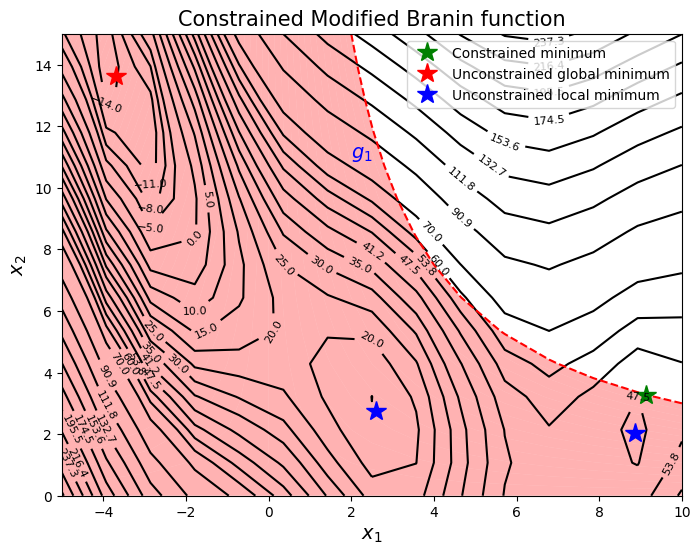

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

def constraint(x):
    """
        Function for computing constraint function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    g = -x1*x2 + 30
    
    return np.expand_dims(g,-1)

# Bounds
lb = np.array([-5, 0])
ub = np.array([10, 15])

# Reshaping into grid
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)
G = constraint(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(35, 60, 5)))
levels = np.concatenate((levels, np.linspace(70, 300, 12)))

fig, ax = plt.subplots(figsize=(8,6))

# Plot function
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid')
ax.clabel(CS, inline=1, fontsize=8)

# Plot constraint
ax.contour(X1, X2, G, levels=[0], colors='r', linestyles='dashed')
ax.contourf(X1, X2, G, levels=np.linspace(0,G.max()), colors="red", alpha=0.3, antialiased = True)
ax.annotate('$g_1$', xy =(2.0, 11.0), fontsize=14, color='b')

# Plot minimum
ax.plot(9.143, 3.281, 'g*', markersize=15, label="Constrained minimum")
ax.plot(-3.689, 13.630, 'r*', markersize=15, label="Unconstrained global minimum")
ax.plot(2.594, 2.741, 'b*', markersize=15, label="Unconstrained local minimum")
ax.plot(8.877, 2.052,'b*', markersize=15)

# Asthetics
ax.set_xlabel("$x_1$", fontsize=14)
ax.set_ylabel("$x_2$", fontsize=14)
ax.set_title("Constrained Modified Branin function", fontsize=15)
ax.legend(loc="upper right")

The goal is to find minimum of the function while satisfying constraint using sequential sampling.